# Load data:

Since we have multiple files based on month for each city, we create a function that can read files based on defined prefixes and combine all files of a given prefix. This function also includes converting datatypes for select columns. Then, we use unionbyName to stack the files on top of each other as every file has the same tabular structure only with varying number of records.

In [1]:
from pyspark.sql import functions as F
from pyspark.sql import DataFrame
from itertools import chain
import time

# Initiating a spark session
spark = SparkSession.builder \
  .appName("AirbnbPriceAnalysis-DataPreprocess") \
  .getOrCreate()

spark
notebook_start_time = time.time()

# Set directory
DIRECTORY = "gs://airbnb-coast/raw/BIA 672 Project/"

# List of prefixes for each city
cities = {
    "alb": "listings_alb",
    "bos": "listings_bos",
    "wdc": "listings_wdc",
    "nyc": "listings_nyc",
    "sd": "listings_sd",
    "sea": "listings_sea",
    "sf": "listings_sf",
    "la": "listings_la",
    "ash": "listings_ash",
    "no": "listings_no",
    "por": "listings_por",
    "oak": "listings_oak",
    "haw": "listings_haw",
    "sc": "listings_sc"
}

# Define the function (selecting only necessary columns and not the whole table
def read_and_process_city(city_prefix: str) -> DataFrame:
   
    df = (
        spark.read
        .option("header", True)
        .option("sep", ",")
        .option("quote", '"')
        .option("escape", '"')
        .option("multiLine", True)
        .csv(f"{DIRECTORY}{city_prefix}*.csv")
        .select(
            "price",
            "calendar_last_scraped",
            "property_type",
            "room_type",
            "accommodates",
            "bathrooms_text",
            "bedrooms",
            "bathrooms",
            "review_scores_rating",
            "review_scores_cleanliness",
            "review_scores_location",
            "host_is_superhost"
        )
    )

    # CDatatype double
    df = df.withColumn(
        "price_numeric",
        F.regexp_replace("price", r"[^0-9.]", "").cast("double")
    )

    # to_date
    df = df.withColumn(
        "calendar_last_scraped_clean",
        F.coalesce(
            F.to_date("calendar_last_scraped", "MM/dd/yyyy"),
            F.to_date("calendar_last_scraped", "yyyy-MM-dd"),
            F.to_date("calendar_last_scraped")
        )
    )

    # Datatype string
    df = (
        df.withColumn("property_type_clean", F.col("property_type").cast("string"))
          .withColumn("room_type_clean", F.col("room_type").cast("string"))
          .withColumn("bathrooms_text_clean", F.col("bathrooms_text").cast("string"))
    )

    # Datatype int
    def safe_int(colname):
        return F.when(F.col(colname).rlike("^[0-9]+$"), F.col(colname).cast("int"))

    df = (
        df.withColumn("accommodates_clean", safe_int("accommodates"))
          .withColumn("bedrooms_clean", safe_int("bedrooms"))
          .withColumn("bathrooms_clean", safe_int("bathrooms"))
          .withColumn("review_scores_rating_clean", safe_int("review_scores_rating"))
          .withColumn("review_scores_cleanliness_clean", safe_int("review_scores_cleanliness"))
          .withColumn("review_scores_location_clean", safe_int("review_scores_location"))
    )

    # Select only the modified columns and drop the priginal raw columns
    df = df.select(
        "price_numeric",
        "calendar_last_scraped_clean",
        "property_type_clean",
        "room_type_clean",
        "accommodates_clean",
        "bathrooms_text_clean",
        "bedrooms_clean",
        "bathrooms_clean",
        "review_scores_rating_clean",
        "review_scores_cleanliness_clean",
        "review_scores_location_clean",
        "host_is_superhost"
    )
    return df

25/12/21 00:06:11 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [2]:
# use the above function for all csv in bucket
list_dfs = {}
for var_name, prefix in cities.items():
    list_dfs[var_name] = read_and_process_city(prefix)

# Global variables for backward compatibility
list_alb = list_dfs["alb"]
list_bos = list_dfs["bos"]
list_la = list_dfs["la"]
list_nyc = list_dfs["nyc"]
list_sd = list_dfs["sd"]
list_sea = list_dfs["sea"]
list_sf = list_dfs["sf"]
list_wdc = list_dfs["wdc"]
list_no = list_dfs["no"]
list_por = list_dfs["por"]
list_oak = list_dfs["oak"]
list_ash = list_dfs["ash"]
list_haw = list_dfs["haw"]
list_sc = list_dfs["sc"]

# Group cities by coast
east_list = [list_nyc, list_bos, list_alb, list_wdc, list_ash, list_no]
west_list = [list_la, list_sf, list_sd, list_sea, list_oak, list_por, list_haw, list_sc]

# Combine east and west coast DataFrames
combined_east_trend = list_nyc.unionByName(list_bos, allowMissingColumns=True) \
                              .unionByName(list_ash, allowMissingColumns=True) \
                              .unionByName(list_no, allowMissingColumns=True) \
                              .unionByName(list_alb, allowMissingColumns=True) \
                              .unionByName(list_wdc, allowMissingColumns=True)

combined_west_trend = list_la.unionByName(list_sf, allowMissingColumns=True) \
                              .unionByName(list_haw, allowMissingColumns=True) \
                              .unionByName(list_sc, allowMissingColumns=True) \
                              .unionByName(list_oak, allowMissingColumns=True) \
                              .unionByName(list_por, allowMissingColumns=True) \
                              .unionByName(list_sd, allowMissingColumns=True) \
                              .unionByName(list_sea, allowMissingColumns=True)

# Pre-process data

1. Following coalesce was commented out because it caused spark failure. It was intended as a way to avoid running the preprocessing over and over and just fetch the combined_east_trend and combined_west_trend files from the bucket for TS roll-ups and Elastic net modelling. 
2. bathrooms_clean column has missing values but the corresponding bathrooms_text_clean has the required information as a string; for example "1 full bath and one shared bath" or "1.5 baths". This is handled using mapping (this part is similar to the preprocessing done for Q1 of our project).
3. We create a function to handle this mapping and filling any missing values with mode and mean as applicable for columns.

In [3]:
'''combined_east_trend.coalesce(1).write.option("header", True).mode("overwrite") \
    .csv(f"{DIRECTORY}/combined_east_trend")
combined_west_trend.coalesce(1).write.option("header", True).mode("overwrite") \
    .csv(f"{DIRECTORY}/combined_west_trend")'''

combined_east_trend = combined_east_trend.cache()

combined_west_trend = combined_west_trend.cache()

# Record counts for verification
print("Number of records in the east dataset:", combined_east_trend.count())
print("Number of records in the west dataset:", combined_west_trend.count())

# fill missing values in `bathrooms` from `bathrooms_text` column
# assume that 1 shared bath counts for 0.5 bathroom,

mapping = {
    '1 shared bath': 0.5, '1 bath': 1.0, '2 baths': 2.0,
    '2 shared baths': 1.0, '1 private bath': 1.0,
    '1.5 shared baths': 0.75, '1.5 baths': 1.5,
    '5.5 baths': 5.5, '2.5 baths': 2.5,
    'Half-bath': 0.5, 'Private half-bath': 0.5,
    '3.5 baths': 3.5, '7 baths': 7.0,
    '4 shared baths': 2.0, '3 baths': 3.0,
    '3 shared baths': 1.5, '4 baths': 4.0,
    '0 baths': 0.0, '0 shared baths': 0.0
}

mapping_expr = F.create_map([F.lit(x) for x in chain(*mapping.items())])

Number of records in the east dataset: 526312


Number of records in the west dataset: 474289


In [4]:
def clean_and_impute_city_df(df):

    # 1. Bathroom mapping
    df = df.withColumn(
        "bathrooms_clean",
        F.coalesce(
            F.col("bathrooms_clean"),
            mapping_expr[F.col("bathrooms_text_clean")]
        )
    )

    # 2. Mode-based columns
    mode_cols = ["bathrooms_clean", "accommodates_clean", "bedrooms_clean"]
    modes = {}

    for c in mode_cols:
        modes[c] = (
            df.filter(F.col(c).isNotNull())
              .groupBy(c)
              .count()
              .orderBy(F.desc("count"))
              .limit(1)
              .collect()[0][0]
        )

    df = df.fillna(modes)

    # 3. Mean-based review scores
    review_cols = [
        "review_scores_rating_clean",
        "review_scores_cleanliness_clean",
        "review_scores_location_clean"
    ]

    means = (
        df.agg(
            *[F.mean(c).alias(c) for c in review_cols]
        )
        .collect()[0]
        .asDict()
    )

    means = {k: v for k, v in means.items() if v is not None}

    if means:
        df = df.fillna(means)

    return df

combined_east_trend = clean_and_impute_city_df(combined_east_trend)
combined_west_trend = clean_and_impute_city_df(combined_west_trend)

# Print schema to verify
combined_east_trend.printSchema()
combined_west_trend.printSchema()

root
 |-- price_numeric: double (nullable = true)
 |-- calendar_last_scraped_clean: date (nullable = true)
 |-- property_type_clean: string (nullable = true)
 |-- room_type_clean: string (nullable = true)
 |-- accommodates_clean: integer (nullable = false)
 |-- bathrooms_text_clean: string (nullable = true)
 |-- bedrooms_clean: integer (nullable = false)
 |-- bathrooms_clean: double (nullable = false)
 |-- review_scores_rating_clean: integer (nullable = true)
 |-- review_scores_cleanliness_clean: integer (nullable = true)
 |-- review_scores_location_clean: integer (nullable = true)
 |-- host_is_superhost: string (nullable = true)

root
 |-- price_numeric: double (nullable = true)
 |-- calendar_last_scraped_clean: date (nullable = true)
 |-- property_type_clean: string (nullable = true)
 |-- room_type_clean: string (nullable = true)
 |-- accommodates_clean: integer (nullable = false)
 |-- bathrooms_text_clean: string (nullable = true)
 |-- bedrooms_clean: integer (nullable = false)
 |--

# EDA for understanding the data

1. We use .describe() to understand the base level price trends on individual cities and on the combined east and west datasets. We can see that each city has its own mean and median prices whcih differ significantly even for cities on one coast (east or west). Thus, the we expect the prediction power of for the elastic net modelling of combined_east_trend and combined_west_trend to be low owing to the significant standard deviation of each dataset.
2. We also create buckets for listing prices to understand the general distribution of prices across each coast.  

In [5]:
# Price stats
print("EAST PRICE STATS:")
combined_east_trend.select("price_numeric").describe().show()
print("WEST PRICE STATS:")
combined_west_trend.select("price_numeric").describe().show()

# Median prices
east_median = combined_east_trend.approxQuantile("price_numeric", [0.5], 0.01)[0]
west_median = combined_west_trend.approxQuantile("price_numeric", [0.5], 0.01)[0]

print("Median price (East):", east_median)
print("Median price (West):", west_median)

# Bucket prices
def bucket_prices(df):
    return df.withColumn(
        "price_bucket",
        F.when(F.col("price_numeric") < 100, "<100")
         .when(F.col("price_numeric") < 200, "100-199")
         .when(F.col("price_numeric") < 300, "200-299")
         .when(F.col("price_numeric") < 500, "300-499")
         .otherwise("500+")
    )

east_buckets = bucket_prices(combined_east_trend)
west_buckets = bucket_prices(combined_west_trend)

east_buckets.groupBy("price_bucket").count().orderBy("price_bucket").show()
west_buckets.groupBy("price_bucket").count().orderBy("price_bucket").show()

EAST PRICE STATS:


+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|            333384|
|   mean|  339.416507690831|
| stddev|2386.2453082271295|
|    min|               3.0|
|    max|          238121.0|
+-------+------------------+

WEST PRICE STATS:
+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|            404695|
|   mean|450.90501735875165|
| stddev| 2480.153133101994|
|    min|               1.0|
|    max|          100000.0|
+-------+------------------+



Median price (East): 144.0
Median price (West): 179.0


+------------+------+
|price_bucket| count|
+------------+------+
|     100-199|116805|
|     200-299| 52544|
|     300-499| 38044|
|        500+|216103|
|        <100|102816|
+------------+------+

+------------+------+
|price_bucket| count|
+------------+------+
|     100-199|140867|
|     200-299| 74777|
|     300-499| 55994|
|        500+|120483|
|        <100| 82168|
+------------+------+



In [6]:
# Define cities by coast
east_cities = {
    "NYC": list_nyc,
    "Boston": list_bos,
    "Albany": list_alb,
    "Washington DC": list_wdc,
    "Asheville": list_ash,
    "New Orleans": list_no
}

west_cities = {
    "LA": list_la,
    "San Francisco": list_sf,
    "San Diego": list_sd,
    "Seattle": list_sea,
    "Oakland": list_oak,
    "Portland": list_por,
    "Hawaii": list_haw,
    "Santa Cruz": list_sc
}

# Function to show stats and median
def describe_city_prices(city_name, df):
    print(f"\nPRICE STATS for {city_name}:")
    df.select("price_numeric").describe().show()
    median = df.approxQuantile("price_numeric", [0.5], 0.01)[0]
    print(f"Median price: {median}")

# East Coast stats
print("=== EAST COAST CITIES ===")
for city, df in east_cities.items():
    describe_city_prices(city, df)

# West Coast stats
print("\n=== WEST COAST CITIES ===")
for city, df in west_cities.items():
    describe_city_prices(city, df)

=== EAST COAST CITIES ===

PRICE STATS for NYC:


+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|            265091|
|   mean|340.34477971715376|
| stddev| 2327.235306543782|
|    min|               3.0|
|    max|           50184.0|
+-------+------------------+



Median price: 145.0

PRICE STATS for Boston:
+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|             18216|
|   mean|412.17792050944223|
| stddev| 3004.977948368624|
|    min|              25.0|
|    max|           50096.0|
+-------+------------------+

Median price: 158.0

PRICE STATS for Albany:
+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|              4841|
|   mean|115.78103697583144|
| stddev|102.65189299860566|
|    min|              24.0|
|    max|            1486.0|
+-------+------------------+

Median price: 94.0

PRICE STATS for Washington DC:
+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|             14487|
|   mean|239.96086146200042|
| stddev|1828.0843372158943|
|    min|              10.0|
|    max|           50000.0|
+-------+------------------+

Median price: 125.0

PRICE STATS for Asheville:
+-------+----------------

+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|            147431|
|   mean| 302.1433416310003|
| stddev|1164.2024041170368|
|    min|               6.0|
|    max|           99999.0|
+-------+------------------+



Median price: 150.0

PRICE STATS for San Francisco:
+-------+-----------------+
|summary|    price_numeric|
+-------+-----------------+
|  count|            23800|
|   mean|350.1720588235294|
| stddev|2264.200498574366|
|    min|              9.0|
|    max|          50000.0|
+-------+-----------------+

Median price: 157.0

PRICE STATS for San Diego:


+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|             46349|
|   mean|491.84249929879826|
| stddev| 2899.620792793534|
|    min|               9.0|
|    max|           50045.0|
+-------+------------------+



Median price: 190.0

PRICE STATS for Seattle:
+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|             24579|
|   mean|344.44867569876726|
| stddev|  2667.98644848804|
|    min|               8.0|
|    max|           50039.0|
+-------+------------------+

Median price: 141.0

PRICE STATS for Oakland:
+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|              8090|
|   mean|198.61557478368357|
| stddev|1409.9487010707435|
|    min|              10.0|
|    max|           40000.0|
+-------+------------------+

Median price: 109.0

PRICE STATS for Portland:
+-------+-----------------+
|summary|    price_numeric|
+-------+-----------------+
|  count|            15346|
|   mean|276.6460315391633|
| stddev|2436.732110133456|
|    min|             12.0|
|    max|          50000.0|
+-------+-----------------+

Median price: 101.0

PRICE STATS for Hawaii:


+-------+-----------------+
|summary|    price_numeric|
+-------+-----------------+
|  count|           128836|
|   mean|685.9265733180167|
| stddev|3323.038453327893|
|    min|              1.0|
|    max|         100000.0|
+-------+-----------------+



Median price: 247.0

PRICE STATS for Santa Cruz:
+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|             10264|
|   mean|400.69738893219017|
| stddev| 2438.446048621221|
|    min|              25.0|
|    max|           54280.0|
+-------+------------------+

Median price: 189.0


# Time Series Roll-up

1. We deine a function to perform monthly, weekly and daily TS roll-ups for the combined_east_trend and combined_west_trend respectively.
2. For better interpretation, we plot the rollups into graphs for visualization

In [7]:
# Function to create time-series rollups
def ts_rollups(df, date_col="calendar_last_scraped_clean", value_col="price_numeric"):
    
    df = df.withColumn(date_col, F.to_date(F.col(date_col), "MM/dd/yyyy"))
    
    # Daily rollup
    daily = df.groupBy(date_col).agg(
        F.count(value_col).alias("count"),
        F.mean(value_col).alias("mean_price"),
        F.expr(f'percentile_approx({value_col}, 0.5)').alias("median_price"),
        F.min(value_col).alias("min_price"),
        F.max(value_col).alias("max_price")
    ).orderBy(date_col)
    
    # Weekly rollup 
    weekly = df.withColumn("year", F.year(date_col)).withColumn("week", F.weekofyear(date_col)) \
        .groupBy("year", "week").agg(
            F.count(value_col).alias("count"),
            F.mean(value_col).alias("mean_price"),
            F.expr(f'percentile_approx({value_col}, 0.5)').alias("median_price"),
            F.min(value_col).alias("min_price"),
            F.max(value_col).alias("max_price")
        ).orderBy("year", "week")
    
    # Monthly rollup
    monthly = df.withColumn("year", F.year(date_col)).withColumn("month", F.month(date_col)) \
        .groupBy("year", "month").agg(
            F.count(value_col).alias("count"),
            F.mean(value_col).alias("mean_price"),
            F.expr(f'percentile_approx({value_col}, 0.5)').alias("median_price"),
            F.min(value_col).alias("min_price"),
            F.max(value_col).alias("max_price")
        ).orderBy("year", "month")
    
    return {"daily": daily, "weekly": weekly, "monthly": monthly}


# East Coast rollups

tr_east_start_time = time.time()
east_rollups = ts_rollups(combined_east_trend)
tr_east_end_time = time.time()
tr_east_runtime = tr_east_end_time - tr_east_start_time
print(f"Total east TR runtime: {tr_east_runtime:.2f} seconds")

print("=== EAST COAST DAILY ROLLUP ===")
east_rollups["daily"].show(10)
print("=== EAST COAST WEEKLY ROLLUP ===")
east_rollups["weekly"].show(10)
print("=== EAST COAST MONTHLY ROLLUP ===")
east_rollups["monthly"].show(10)


# West Coast rollups

tr_west_start_time = time.time()
west_rollups = ts_rollups(combined_west_trend)
tr_west_end_time = time.time()
tr_west_runtime = tr_west_end_time - tr_west_start_time
print(f"Total west TR runtime: {tr_west_runtime:.2f} seconds")

print("=== WEST COAST DAILY ROLLUP ===")
west_rollups["daily"].show(10)
print("=== WEST COAST WEEKLY ROLLUP ===")
west_rollups["weekly"].show(10)
print("=== WEST COAST MONTHLY ROLLUP ===")
west_rollups["monthly"].show(10)

Total east TR runtime: 0.29 seconds
=== EAST COAST DAILY ROLLUP ===


+---------------------------+-----+------------------+------------+---------+---------+
|calendar_last_scraped_clean|count|        mean_price|median_price|min_price|max_price|
+---------------------------+-----+------------------+------------+---------+---------+
|                 2024-11-04|22741|216.73765445670816|       149.0|      8.0|  20000.0|
|                 2024-11-05|  383|118.96605744125327|       100.0|     24.0|   1379.0|
|                 2024-11-09|    1|             185.0|       185.0|    185.0|    185.0|
|                 2024-12-04| 5053|136.88462299623987|        99.0|     10.0|  10000.0|
|                 2024-12-05|18332|242.43846825223653|       159.0|      8.0|  20000.0|
|                 2024-12-07|  391|116.24296675191816|        99.0|     24.0|   1379.0|
|                 2024-12-08| 6285|214.91328560063644|       146.0|     10.0|  16740.0|
|                 2024-12-18| 7554| 164.8559703468361|       120.0|     14.0|   7000.0|
|                 2024-12-20| 73

+----+----+-----+------------------+------------+---------+---------+
|year|week|count|        mean_price|median_price|min_price|max_price|
+----+----+-----+------------------+------------+---------+---------+
|2024|  45|23125|215.11697297297297|       148.0|      8.0|  20000.0|
|2024|  49|30061| 217.2995243005888|       142.0|      8.0|  20000.0|
|2024|  51|14926|174.64759480101836|       126.0|     14.0|  10000.0|
|2025|   1|23363| 193.9160638616616|       130.0|      8.0|  20000.0|
|2025|   3|    1|             113.0|       113.0|    113.0|    113.0|
|2025|   5|23195|194.79051519724078|       130.0|      8.0|  20000.0|
|2025|   6|  379| 109.4221635883905|        93.0|     24.0|    882.0|
|2025|   9|20585|274.87578333738156|       170.0|      7.0| 238121.0|
|2025|  10| 8737|205.01785509900424|       129.0|     19.0|  33757.0|
|2025|  11| 8412|182.04018069424632|       144.0|     10.0|   9751.0|
+----+----+-----+------------------+------------+---------+---------+
only showing top 10 

+----+-----+-----+------------------+------------+---------+---------+
|year|month|count|        mean_price|median_price|min_price|max_price|
+----+-----+-----+------------------+------------+---------+---------+
|2024|   11|23125|215.11697297297297|       148.0|      8.0|  20000.0|
|2024|   12|44987|203.14826505434903|       135.0|      8.0|  20000.0|
|2025|    1|23364| 193.9126005820921|       130.0|      8.0|  20000.0|
|2025|    2|23574|193.41804530414865|       130.0|      8.0|  20000.0|
|2025|    3|37734| 238.0050087454285|       152.0|      7.0| 238121.0|
|2025|    4|22533|220.45386766076422|       143.0|      8.0|  20000.0|
|2025|    5|22246|231.67342443585363|       150.0|      8.0|  20000.0|
|2025|    6|39324|502.14423761570544|       148.0|      8.0|  50184.0|
|2025|    7|21741| 518.9182190331632|       150.0|     10.0|  50083.0|
|2025|    8|21698|441.50391741174303|       150.0|      3.0|  50052.0|
+----+-----+-----+------------------+------------+---------+---------+
only s

+---------------------------+-----+------------------+------------+---------+---------+
|calendar_last_scraped_clean|count|        mean_price|median_price|min_price|max_price|
+---------------------------+-----+------------------+------------+---------+---------+
|                 2024-12-04| 6228| 239.1029222864483|       148.0|     25.0|  50000.0|
|                 2024-12-06|27111|236.13846778060565|       128.0|      6.0|  99999.0|
|                 2024-12-07|15202| 318.0992632548349|       161.0|     10.0|  23286.0|
|                 2024-12-12| 7164|451.17755443886097|       199.0|     10.0|  20000.0|
|                 2024-12-13|24823| 403.3115658864763|       245.0|      8.0|  25000.0|
|                 2024-12-22| 2137| 151.5657463734207|       110.0|     20.0|   3500.0|
|                 2024-12-23|17783|271.74391272563685|       163.0|      8.0|  11998.0|
|                 2024-12-25|    1|             801.0|       801.0|    801.0|    801.0|
|                 2024-12-31| 15

+----+----+-----+------------------+------------+---------+---------+
|year|week|count|        mean_price|median_price|min_price|max_price|
+----+----+-----+------------------+------------+---------+---------+
|2024|   1| 1571|339.42011457670276|       264.0|     40.0|   7261.0|
|2024|  49|48541| 262.1871819698811|       145.0|      6.0|  99999.0|
|2024|  50|31987|  414.031919217182|       236.0|      8.0|  25000.0|
|2024|  51| 2137| 151.5657463734207|       110.0|     20.0|   3500.0|
|2024|  52|17784|271.77367296446243|       163.0|      8.0|  11998.0|
|2025|   9|15970|267.57401377582966|       144.0|      9.0|  50000.0|
|2025|  10|37634|317.23717914651644|       166.0|      9.0|  99999.0|
|2025|  11|31176|379.34965999486786|       228.0|      1.0|  25010.0|
|2025|  12|12237| 281.7532892048705|       178.0|     11.0|  11316.0|
|2025|  13| 1469|325.73179033356024|       252.0|     37.0|   8881.0|
+----+----+-----+------------------+------------+---------+---------+
only showing top 10 

+----+-----+------+------------------+------------+---------+---------+
|year|month| count|        mean_price|median_price|min_price|max_price|
+----+-----+------+------------------+------------+---------+---------+
|2024|   12|102020| 310.3392962164281|       175.0|      6.0|  99999.0|
|2025|    3| 98486| 324.5637044859168|       183.0|      1.0|  99999.0|
|2025|    4|    54|  310.037037037037|       272.0|     85.0|    900.0|
|2025|    6| 94659| 498.3795096081725|       185.0|      7.0|  54280.0|
|2025|    7| 10393|1168.4454921581835|       225.0|     19.0| 100000.0|
|2025|    9| 99083| 600.6752722465004|       178.0|      8.0|  85000.0|
+----+-----+------+------------------+------------+---------+---------+



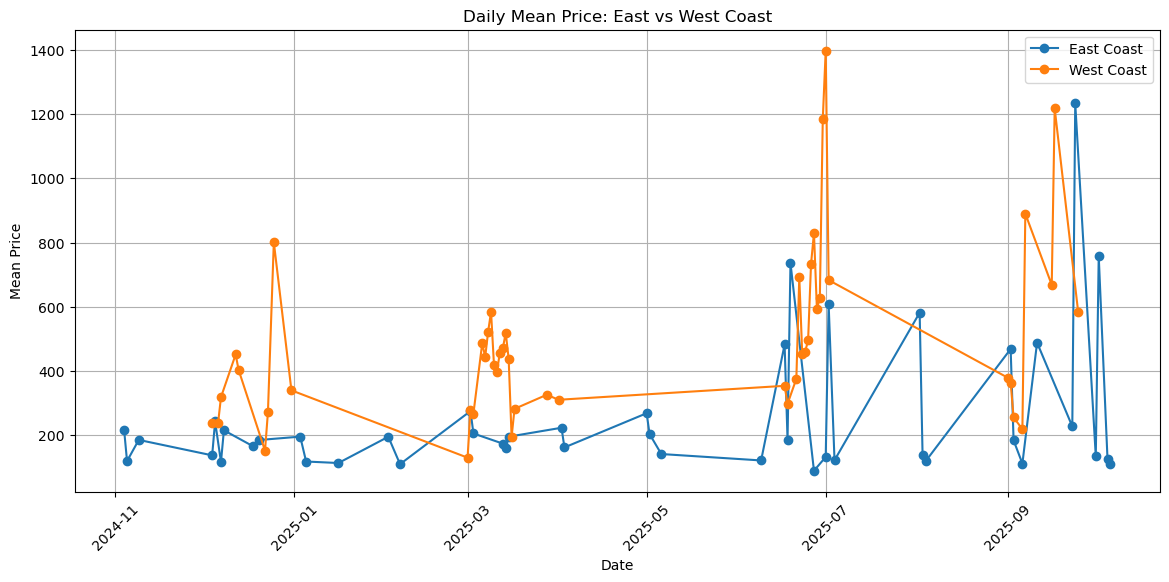

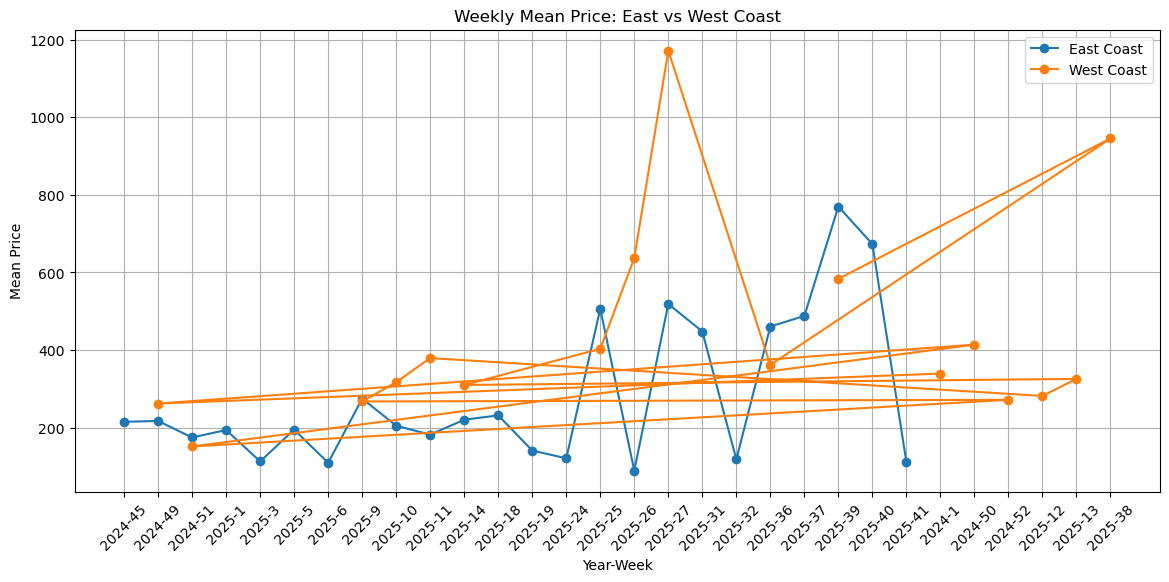

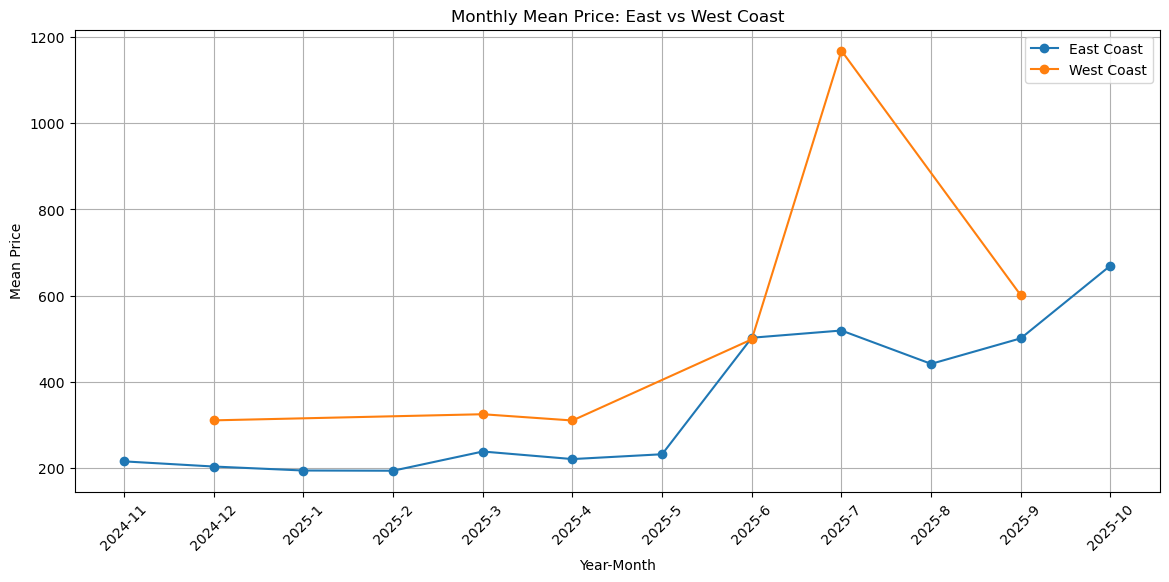

In [8]:
import matplotlib.pyplot as plt

# Daily Roll-up plot
east_daily = east_rollups["daily"].select("calendar_last_scraped_clean", "mean_price")
west_daily = west_rollups["daily"].select("calendar_last_scraped_clean", "mean_price")

east_daily_pd = east_daily.toPandas()
west_daily_pd = west_daily.toPandas()

plt.figure(figsize=(14,6))
plt.plot(east_daily_pd["calendar_last_scraped_clean"], east_daily_pd["mean_price"], label="East Coast", marker='o')
plt.plot(west_daily_pd["calendar_last_scraped_clean"], west_daily_pd["mean_price"], label="West Coast", marker='o')
plt.title("Daily Mean Price: East vs West Coast")
plt.xlabel("Date")
plt.ylabel("Mean Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# Weekly Rollup plot
east_weekly = east_rollups["weekly"].withColumn("year_week", F.concat_ws("-", F.col("year"), F.col("week")))
west_weekly = west_rollups["weekly"].withColumn("year_week", F.concat_ws("-", F.col("year"), F.col("week")))

east_weekly_pd = east_weekly.select("year_week", "mean_price").toPandas()
west_weekly_pd = west_weekly.select("year_week", "mean_price").toPandas()

plt.figure(figsize=(14,6))
plt.plot(east_weekly_pd["year_week"], east_weekly_pd["mean_price"], label="East Coast", marker='o')
plt.plot(west_weekly_pd["year_week"], west_weekly_pd["mean_price"], label="West Coast", marker='o')
plt.title("Weekly Mean Price: East vs West Coast")
plt.xlabel("Year-Week")
plt.ylabel("Mean Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# Monthly Rollup Plot
east_monthly = east_rollups["monthly"].withColumn("year_month", F.concat_ws("-", F.col("year"), F.col("month")))
west_monthly = west_rollups["monthly"].withColumn("year_month", F.concat_ws("-", F.col("year"), F.col("month")))

east_monthly_pd = east_monthly.select("year_month", "mean_price").toPandas()
west_monthly_pd = west_monthly.select("year_month", "mean_price").toPandas()

plt.figure(figsize=(14,6))
plt.plot(east_monthly_pd["year_month"], east_monthly_pd["mean_price"], label="East Coast", marker='o')
plt.plot(west_monthly_pd["year_month"], west_monthly_pd["mean_price"], label="West Coast", marker='o')
plt.title("Monthly Mean Price: East vs West Coast")
plt.xlabel("Year-Month")
plt.ylabel("Mean Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# Elastic Net modelling for east and west coast

We build a pipeline for elastic net modelling (Linear regression was used as GBT overwhelmed the cluster) to train the combined_east_trend and combined_west_trend on diffecnt sample sizes. We also test this pipeline for each individual city and the results who that for certain cities like Albany, Boston and Seattle, the model performcane is descent while the model performs poorly for cities like LA and Santa Cruz.

# Sample Sizes
1. 100% data
2. ~50% data (From January to June 2025)
3. ~25% data (from April to June 2025)

In [9]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [10]:
def build_pipeline():

    categorical_cols = [
        "property_type_clean",
        "room_type_clean"
    ]

    indexers = [
        StringIndexer(
            inputCol=c,
            outputCol=f"{c}_index",
            handleInvalid="keep"
        )
        for c in categorical_cols
    ]

    encoder = OneHotEncoder(
        inputCols=[f"{c}_index" for c in categorical_cols],
        outputCols=[f"{c}_vec" for c in categorical_cols],
        handleInvalid="keep"
    )

    numeric_cols = [
        "accommodates_clean",
        "bedrooms_clean",
        "bathrooms_clean",
        "review_scores_rating_clean",
        "review_scores_cleanliness_clean",
        "review_scores_location_clean",
        "host_is_superhost_num"
    ]

    assembler_input_cols = numeric_cols + [f"{c}_vec" for c in categorical_cols]

    assembler = VectorAssembler(
        inputCols=assembler_input_cols,
        outputCol="features",
        handleInvalid="keep"   
    )

    lr = LinearRegression(
        featuresCol="features",
        labelCol="price_numeric"
    )

    pipeline = Pipeline(stages=indexers + [encoder, assembler, lr])

    return pipeline, lr


def train_pipeline(df, name, cv_folds=3):

    df = df.filter(
        F.col("price_numeric").isNotNull() &
        (~F.isnan(F.col("price_numeric")))
    )

    if df.count() == 0:
        print(f"No valid rows for {name}")
        return None

    print(f"\n=== TRAINING MODEL: {name.upper()} ===")

    pipeline, lr = build_pipeline()

    train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

    paramGrid = (
        ParamGridBuilder()
        .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
        .addGrid(lr.regParam, [0.01, 0.1, 0.5])
        .build()
    )

    evaluator_rmse = RegressionEvaluator(
        labelCol="price_numeric",
        predictionCol="prediction",
        metricName="rmse"
    )

    evaluator_mae = RegressionEvaluator(
        labelCol="price_numeric",
        predictionCol="prediction",
        metricName="mae"
    )

    evaluator_r2 = RegressionEvaluator(
        labelCol="price_numeric",
        predictionCol="prediction",
        metricName="r2"
    )

    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=paramGrid,
        evaluator=evaluator_rmse,  # CV optimized on RMSE
        numFolds=cv_folds,
        parallelism=2
    )

    cv_model = cv.fit(train_df)
    best_model = cv_model.bestModel

    predictions = best_model.transform(test_df)

    rmse = evaluator_rmse.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)

    print(
        f"{name} → "
        f"RMSE: {rmse:.2f}, "
        f"MAE: {mae:.2f}, "
        f"R²: {r2:.3f}"
    )

    return {
        "model": best_model,
        "predictions": predictions,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

# Preprare the dataset and run pipeline 

def prepare_boolean_cols(df):
    return df.withColumn(
        "host_is_superhost_num",
        F.when(F.lower(F.col("host_is_superhost")).isin("t", "true", "yes"), 1.0)
         .when(F.lower(F.col("host_is_superhost")).isin("f", "false", "no"), 0.0)
         .otherwise(0.0)
    )

datasets = {
    "east": combined_east_trend,
    "west": combined_west_trend
}

numeric_cols = [
    "accommodates_clean",
    "bedrooms_clean",
    "bathrooms_clean",
    "review_scores_rating_clean",
    "review_scores_cleanliness_clean",
    "review_scores_location_clean",
    "host_is_superhost_num"
]


for name, df in datasets.items():
    df = prepare_boolean_cols(df)
    for c in numeric_cols:
        df = df.withColumn(c, F.when(F.col(c).isNull(), 0.0).otherwise(F.col(c)))
    datasets[name] = df  

results = {}

for name, df in datasets.items():
    
    full_start_time = time.time()
    results[name] = train_pipeline(df, name)
    full_end_time = time.time()
    full_runtime = full_end_time - full_start_time
    print(f"Total full runtime: {full_runtime:.2f} seconds")


=== TRAINING MODEL: EAST ===


east → RMSE: 2068.64, MAE: 327.60, R²: 0.212
Total full runtime: 89.31 seconds

=== TRAINING MODEL: WEST ===


west → RMSE: 2376.31, MAE: 456.79, R²: 0.137
Total full runtime: 73.22 seconds


In [11]:
# Function to seperate data for Q1 and Q2
def filter_quarter(df, quarter):
    if quarter == "Q1":  # Jun → Apr
        return df.filter(F.col("calendar_last_scraped_clean").substr(6,2).cast("int").isin([6,4,5]))
    elif quarter == "Q2":  # Jan → Feb
        return df.filter(F.col("calendar_last_scraped_clean").substr(6,2).cast("int").isin([1,2,3,4,5,6]))
    else:
        return df
    
quarters = ["Q1", "Q2"]

results = {}

for city_name, df in datasets.items():
    for q in quarters:
        df_q = filter_quarter(df, q)
        key = f"{city_name}_{q}"
        print(f"\nRunning pipeline for {key} ...")

        start_time = time.time()
        results[key] = train_pipeline(df_q, key)
        end_time = time.time()
        runtime = end_time - start_time
        print(f"Total runtime: {runtime:.2f} seconds")



Running pipeline for east_Q1 ...

=== TRAINING MODEL: EAST_Q1 ===


east_Q1 → RMSE: 2030.30, MAE: 351.58, R²: 0.244
Total runtime: 44.39 seconds

Running pipeline for east_Q2 ...

=== TRAINING MODEL: EAST_Q2 ===


east_Q2 → RMSE: 1530.67, MAE: 246.51, R²: 0.118
Total runtime: 48.57 seconds

Running pipeline for west_Q1 ...

=== TRAINING MODEL: WEST_Q1 ===


west_Q1 → RMSE: 2580.11, MAE: 481.00, R²: 0.268
Total runtime: 49.19 seconds

Running pipeline for west_Q2 ...

=== TRAINING MODEL: WEST_Q2 ===


west_Q2 → RMSE: 2026.86, MAE: 366.07, R²: 0.130
Total runtime: 53.53 seconds


In [12]:
city = {
"Albany":list_alb,
"Boston":list_bos,
"LA":list_la,
"NYC":list_nyc,
"San_D":list_sd,
"Seattle":list_sea,
"San_F":list_sf,
"WDC":list_wdc,
"Asheville": list_ash,
"New Orleans": list_no,
"Oakland": list_oak,
"Portland": list_por,
"Hawaii": list_haw,
"Santa Cruz": list_sc   
}

result_city = {}

for city_name, df in city.items():  

    print(f"\n=== PROCESSING CITY: {city_name.upper()} ===")

    # Use clean and impute
    df = clean_and_impute_city_df(df)

    # Prepare boolean columns
    df = prepare_boolean_cols(df)

    # Handle missing values
    for c in numeric_cols:
        df = df.withColumn(c, F.when(F.col(c).isNull() | F.isnan(F.col(c)), 0.0).otherwise(F.col(c)))

    # Apply pipeline
    result_city[city_name] = train_pipeline(df, city_name)


=== PROCESSING CITY: ALBANY ===

=== TRAINING MODEL: ALBANY ===


Albany → RMSE: 85.19, MAE: 36.57, R²: 0.478

=== PROCESSING CITY: BOSTON ===



=== TRAINING MODEL: BOSTON ===


Boston → RMSE: 2358.64, MAE: 454.80, R²: 0.334

=== PROCESSING CITY: LA ===



=== TRAINING MODEL: LA ===


LA → RMSE: 1292.89, MAE: 230.73, R²: 0.076

=== PROCESSING CITY: NYC ===


ERROR:root:Exception while sending command.                                     
Traceback (most recent call last):
  File "/usr/lib/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/opt/conda/miniconda3/lib/python3.11/site-packages/IPython/core

ConnectionRefusedError: [Errno 111] Connection refused

In [ ]:
notebook_end_time = time.time()
total_runtime = notebook_end_time - notebook_start_time
print(f"Total notebook runtime: {total_runtime:.2f} seconds")